# Generador de palabras para OCR
Herramienta para generar dataset de imagenes sinteticas de fuentes

## Importación de Librerias

In [1]:
#Importo librerias a utilizar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import cv2
import random
from PIL import Image, ImageFilter, ImageDraw, ImageFont
from IPython.display import Image as ImageDisplay
from IPython.core.display import HTML
from io import BytesIO
import base64
from sklearn.model_selection import train_test_split

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Variables de configuracion
archivo_zip_fuentes = '/content/drive/MyDrive/tp_integrador/fuentes.zip'
carpeta_destino = '/content/fuentes'
carpeta_destino_datasets = '/content/datasets'
rango_tamanio_fuente = (48,100)
tamanio_imagen = 128 #imagenes cuadradas
characters_to_generate = "ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789" # Caracteres del diccionario

## Generacion de imagenes

In [5]:
#Descomprimo las fuentes
!unzip {archivo_zip_fuentes} -d {carpeta_destino}

Archive:  /content/drive/MyDrive/tp_integrador/fuentes.zip
  inflating: /content/fuentes/ocr_fonts_latin/Noto_Sans_Nag_Mundari/Noto_Sans_Nag_Mundari-700.ttf  
  inflating: /content/fuentes/ocr_fonts_latin/Noto_Sans_Mayan_Numerals/Noto_Sans_Mayan_Numerals-regular.ttf  
  inflating: /content/fuentes/ocr_fonts_latin/Noto_Sans_Oriya/Noto_Sans_Oriya-600.ttf  
  inflating: /content/fuentes/ocr_fonts_latin/Noto_Sans_NKo_Unjoined/Noto_Sans_NKo_Unjoined-regular.ttf  
  inflating: /content/fuentes/ocr_fonts_latin/Noto_Sans_Meetei_Mayek/Noto_Sans_Meetei_Mayek-800.ttf  
  inflating: /content/fuentes/ocr_fonts_latin/Noto_Sans_Meetei_Mayek/Noto_Sans_Meetei_Mayek-700.ttf  
  inflating: /content/fuentes/ocr_fonts_latin/Noto_Sans_Meetei_Mayek/Noto_Sans_Meetei_Mayek-500.ttf  
  inflating: /content/fuentes/ocr_fonts_latin/Noto_Sans_NKo_Unjoined/Noto_Sans_NKo_Unjoined-700.ttf  
  inflating: /content/fuentes/ocr_fonts_latin/Noto_Sans_Nag_Mundari/Noto_Sans_Nag_Mundari-regular.ttf  
  inflating: /content/fue

## Funciones auxiliares

In [6]:
def get_bbox_from_image(image_array):
    """
    Toma un array NumPy de una imagen en escala de grises, encuentra los contornos,
    los combina y devuelve las coordenadas de la bounding box en formato
    (x_min, y_min, x_max, y_max).

    Args:
        image_array (np.ndarray): Una imagen en escala de grises como un array NumPy.

    Returns:
        tuple: Una tupla (x_min, y_min, x_max, y_max) que representa la bounding box.
               Retorna None si no se encuentran contornos.
    """
    # Asegurarse de que la imagen esté en escala de grises si no lo está ya
    if len(image_array.shape) == 3:
        gray_image = cv2.cvtColor(image_array, cv2.COLOR_BGR2GRAY)
    else:
        gray_image = image_array

    # Binarizar la imagen si es necesario para asegurar buenos contornos
    # Esto es crucial si la imagen de entrada tiene tonos de gris en lugar de solo blanco/negro
    # Ajusta el umbral (e.g., 127) y el tipo (e.g., cv2.THRESH_BINARY_INV) según tus imágenes.
    _, binary_image = cv2.threshold(gray_image, 127, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)


    # Encontrar contornos
    # cv2.RETR_EXTERNAL recupera solo los contornos externos (útil para caracteres con agujeros internos)
    contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        binary_image=cv2.bitwise_not(binary_image)
        contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return None # No se encontraron contornos

    # Combinar todos los contornos en uno solo (para caracteres con múltiples partes como 'i' o 'j')
    # Solo apilamos si hay contornos válidos (size > 0)
    valid_contours = [c.squeeze() for c in contours if c.size > 0]
    if not valid_contours:
        return None # No se encontraron contornos válidos después de limpiar

    all_points = np.vstack(valid_contours)

    # Encontrar el rectángulo delimitador para el contorno combinado
    x, y, w, h = cv2.boundingRect(all_points)

    # Retornar en el formato (x_min, y_min, x_max, y_max)
    x_min, y_min = x, y
    x_max, y_max = x + w, y + h

    return (x_min, y_min, x_max, y_max)

## Generacion del dataset de fuentes

In [7]:
#Creo un dataset con las fuentes
def create_font_dataset(base_folder):
    """
    Crea un DataFrame de Pandas con información sobre las fuentes TTF encontradas.

    Args:
        base_folder (str): Ruta a la carpeta principal que contiene las subcarpetas de tipos de letra.

    Returns:
        pd.DataFrame: DataFrame con columnas 'font_name' y 'font_path'.
    """
    font_data = []
    print(f"Buscando archivos .ttf en: {base_folder}")
    for root, dirs, files in os.walk(base_folder):
        for file in files:
            # Comprobamos si el archivo termina con '.ttf' o '.otf' (sin importar mayúsculas/minúsculas)
            if file.lower().endswith(('.ttf', '.otf')):
                # Si es una fuente, añadimos la ruta completa a la lista
                full_font_path = os.path.join(root, file)
                full_font_path = full_font_path.replace('\\', '/').replace('//','/')
                font_file_name = file
                font_name = os.path.splitext(font_file_name)[0]
                font_data.append({
                    'font_name': font_name, # Usamos el nombre de la carpeta como nombre de la fuente
                    'font_path': full_font_path
                })

    return pd.DataFrame(font_data)

In [8]:
font_df = create_font_dataset(carpeta_destino)
font_df.info()

Buscando archivos .ttf en: /content/fuentes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3934 entries, 0 to 3933
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   font_name  3934 non-null   object
 1   font_path  3934 non-null   object
dtypes: object(2)
memory usage: 61.6+ KB


## Generacion dataset de imagenes

In [9]:
# prompt: quiero una funcion que reciba una imagen de cv en escala de grises y le aplique blur gausieano y la devuelva en el mismo formato

def apply_gaussian_blur(image_gray, ksize=(5, 5), sigmaX=0):
    """
    Aplica un filtro de desenfoque Gaussiano a una imagen en escala de grises.

    Args:
        image_gray (np.ndarray): Imagen de entrada en escala de grises (array NumPy).
        ksize (tuple): Tamaño del kernel Gaussiano. Debe ser una tupla de números
                       enteros impares positivos (ancho, alto).
        sigmaX (float): Desviación estándar del kernel en la dirección X. Si es 0,
                        se calcula automáticamente en función del tamaño del kernel.

    Returns:
        np.ndarray: La imagen desenfocada como un array NumPy en escala de grises.
    """
    if len(image_gray.shape) != 2:
        print("Advertencia: La imagen de entrada no está en escala de grises. Intentando convertir.")
        image_gray = cv2.cvtColor(image_gray, cv2.COLOR_BGR2GRAY)

    blurred_image = cv2.GaussianBlur(image_gray, ksize, sigmaX)
    return blurred_image


In [10]:
#Invierte colores imagen
def invert_colors(image_gray):
  return 255 - image_gray

In [11]:
# prompt: quiero una funcion que reciba una imagen de opencv en escala de grises y la rote 5 o -5 grados y devuelva en el mismo formato

def rotate_image(image_gray, angle, color=(0, 0, 0)):
    if len(image_gray.shape) != 2:
        print("Advertencia: La imagen de entrada no está en escala de grises. Intentando convertir.")
        image_gray = cv2.cvtColor(image_gray, cv2.COLOR_BGR2GRAY)

    (h, w) = image_gray.shape[:2]
    center = (w // 2, h // 2)

    # Calcular la matriz de rotación
    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    # Calcular las nuevas dimensiones de la imagen para evitar recortes
    cos = np.abs(M[0, 0])
    sin = np.abs(M[0, 1])
    nW = int((h * sin) + (w * cos))
    nH = int((h * cos) + (w * sin))

    # Ajustar la matriz de translación para que el centro permanezca en el centro de la nueva imagen
    M[0, 2] += (nW / 2) - center[0]
    M[1, 2] += (nH / 2) - center[1]

    # Realizar la rotación, manteniendo el fondo negro (0)
    rotated_image = cv2.warpAffine(image_gray, M, (nW, nH), borderValue=color)

    return rotated_image


In [16]:
def create_noise_background(image_shape, gray_center=128, noise_amplitude=50):
    """
    Crea un fondo de ruido aleatorio predominantemente gris, con cierta variación.

    Args:
        image_shape (tuple): Las dimensiones (altura, anchura) de la imagen.
        gray_center (int): El valor central de gris para el ruido (0-255).
        noise_amplitude (int): La amplitud del ruido alrededor del centro.
                               Por ejemplo, 50 significa ruido entre [centro-50, centro+50].

    Returns:
        np.ndarray: Un array NumPy que representa el fondo de ruido.
    """
    # Genera ruido en un rango limitado alrededor del centro
    # np.random.normal para un ruido más natural (gaussiano) o randint para uniforme.
    # Usaremos randint para simplificar y controlar el rango.

    # Calcular el rango min y max para el ruido
    min_val = max(0, gray_center - noise_amplitude)
    max_val = min(255, gray_center + noise_amplitude)

    # Genera el ruido y lo escala al rango deseado
    noise = np.random.randint(min_val, max_val + 1, image_shape, dtype=np.uint8)
    return noise

def get_bbox_from_image_array(image_array):
    """
    Toma un array NumPy de una imagen en escala de grises, encuentra los contornos,
    los combina y devuelve las coordenadas de la bounding box en formato
    (x_min, y_min, x_max, y_max).

    Args:
        image_array (np.ndarray): Una imagen en escala de grises como un array NumPy.

    Returns:
        tuple: Una tupla (x_min, y_min, x_max, y_max) que representa la bounding box.
               Retorna None si no se encuentran contornos.
    """
    # Asegurarse de que la imagen esté en escala de grises si no lo está ya
    if len(image_array.shape) == 3:
        gray_image = cv2.cvtColor(image_array, cv2.COLOR_BGR2GRAY)
    else:
        gray_image = image_array

    # Binarizar la imagen si es necesario para asegurar buenos contornos
    # Esto es crucial si la imagen de entrada tiene tonos de gris en lugar de solo blanco/negro
    # Ajusta el umbral (e.g., 127) y el tipo (e.g., cv2.THRESH_BINARY_INV) según tus imágenes.
    _, binary_image = cv2.threshold(gray_image, 127, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)


    # Encontrar contornos
    # cv2.RETR_EXTERNAL recupera solo los contornos externos (útil para caracteres con agujeros internos)
    contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        binary_image=cv2.bitwise_not(binary_image)
        contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return None # No se encontraron contornos

    # Combinar todos los contornos en uno solo (para caracteres con múltiples partes como 'i' o 'j')
    # Solo apilamos si hay contornos válidos (size > 0)
    valid_contours = [c.squeeze() for c in contours if c.size > 0]
    if not valid_contours:
        return None # No se encontraron contornos válidos después de limpiar

    all_points = np.vstack(valid_contours)

    # Encontrar el rectángulo delimitador para el contorno combinado
    x, y, w, h = cv2.boundingRect(all_points)

    # Retornar en el formato (x_min, y_min, x_max, y_max)
    x_min, y_min = x, y
    x_max, y_max = x + w, y + h

    return (x_min, y_min, x_max, y_max)


# --- Generación de Imagen Base y Bbox (con Pillow) ---
def generate_base_char_image_and_bbox(char, font_path, font_size=200, img_size=(256, 256)):
    """
    Genera la imagen base de un caracter (blanco sobre fondo negro) usando Pillow
    y calcula su bounding box.
    """
    fuentes_erroneas=[]
    try:
        font = ImageFont.truetype(font_path, font_size)
    except IOError:
        print(f"Advertencia: No se pudo cargar la fuente {font_path}. Retornando None.")
        fuentes_erroneas.append(font_path)
        return None, None, fuentes_erroneas
    except Exception as e:
        print(f"Error al cargar la fuente {font_path}: {e}. Retornando None.")
        fuentes_erroneas.append(font_path)
        return None, None, fuentes_erroneas

    # Crear imagen con caracter blanco sobre fondo negro
    img_black_bg_white_char_pil = Image.new('L', img_size, color=0) # Fondo negro
    draw = ImageDraw.Draw(img_black_bg_white_char_pil)

    # Calcular posición para centrar el texto
    # Usar textbbox para obtener dimensiones del texto renderizado
    try:
        text_bbox = draw.textbbox((0,0), char, font=font)
    except Exception as e:
        print(f"Error al obtener textbbox para '{char}' con {font_path}: {e}. Retornando None.")
        return None, None, fuentes_erroneas

    text_width = text_bbox[2] - text_bbox[0]
    text_height = text_bbox[3] - text_bbox[1]
    x_center = (img_size[0] - text_width) / 2 - text_bbox[0]
    y_center = (img_size[1] - text_height) / 2 - text_bbox[1]

    draw.text((x_center, y_center), char, font=font, fill=255) # Caracter blanco
    img_np = np.array(img_black_bg_white_char_pil) # Convertir a NumPy array

    # Calcular bbox usando la función de OpenCV
    bbox = get_bbox_from_image_array(img_np)

    return img_np, bbox, fuentes_erroneas

def generate_variations_from_base(base_image_np, bbox):
    """
    Genera las 5 variaciones adicionales de una imagen de caracter
    a partir de una imagen base (caracter blanco sobre fondo negro).
    """
    variations = []

    # --- Variaciones con blur ---
    img_blur_black = base_image_np.copy()
    img_blur_black = apply_gaussian_blur(img_blur_black)
    variations.append((img_blur_black.copy(), "blur", "blanco"))

    #Variacion fondo blanco
    img_invert = base_image_np.copy()
    img_invert = invert_colors(img_invert)
    variations.append((img_invert.copy(), "invert", "negro"))

    #variacion fondo noise
    noise_background = create_noise_background(base_image_np.shape)
    imagen_noise = np.where(base_image_np.copy() == 0, noise_background, base_image_np.copy())
    # Asegúrate de que el tipo de datos sea uint8 para OpenCV
    imagen_noise = imagen_noise.astype(np.uint8)
    variations.append((imagen_noise.copy(), "noise", "blanco"))


    # --- Variaciones con rotacion ---
    img_rotate_black_1 = base_image_np.copy()
    img_rotate_black_1 = rotate_image(img_rotate_black_1, 5, (0, 0, 0))
    img_rotate_black_1 = cv2.resize(img_rotate_black_1, (base_image_np.shape[1], base_image_np.shape[0]))
    variations.append((img_rotate_black_1, "rotate", "blanco"))
    img_rotate_black_2 = base_image_np.copy()
    img_rotate_black_2 = rotate_image(img_rotate_black_2, -5, (0, 0, 0))
    img_rotate_black_2 = cv2.resize(img_rotate_black_2, (base_image_np.shape[1], base_image_np.shape[0]))
    variations.append((img_rotate_black_2, "rotate", "blanco"))

    return variations

In [13]:
#Eliminar furntes erroneas del disco y del dataset
def eliminar_fuente(fuentes_erroneas, font_df):
    if fuentes_erroneas:
        for fuente in fuentes_erroneas:
            try:
                #path_corregido = fuente.replace('/', '\\') para windows
                path_corregido = fuente.replace('\\', '/') #para linux o colab
                os.remove(path_corregido)
                print(f"fuente {path_corregido} eliminada")
            except: # si no funciona pruebo por linea de comandos
                try:
                    #!del /f /q "{path_corregido}" #para windows
                    !rm -f "{path_corregido}" #para linux o colab
                    print(f"fuente {path_corregido} eliminada")
                except:
                    print(f"no se pudo eliminar la fuente {path_corregido}")
            font_df = font_df[font_df['font_path'] != fuente]
    return font_df

In [14]:
# --- Función para generar los datasets principales ---
def generate_full_datasets(font_df, characters_to_generate, rango_tamanio_fuente, tamanio_imagen):
    """
    Genera el dataset de NumPy y Pandas a partir de las fuentes TTF.

    Args:
        font_df: dataset de fuentes.

    Returns:
        tuple: (numpy_dataset, pandas_dataset)
    """

    numpy_data_list = []
    pandas_data = []
    global_index = 0
    font_df_corregido = font_df
    fuentes_erroneas=[]


    if font_df.empty:
        print("No se encontraron fuentes para procesar.")
        return np.array([], dtype=[('image', object), ('bbox', object), ('index', int)]), pd.DataFrame()

    for index, font_row in font_df.iterrows():
        font_name = font_row['font_name']
        font_path = font_row['font_path']
        print(f"Generando caracteres para la fuente: {font_name} ({font_path})")

        for char in characters_to_generate:
            # Generar la imagen base (carácter blanco sobre fondo negro) y su bbox con Pillow
            tamanio_fuente = random.randint(rango_tamanio_fuente[0], rango_tamanio_fuente[1])
            base_image_np, bbox, fuentes_error = generate_base_char_image_and_bbox(char, font_path, font_size=tamanio_fuente, img_size=(tamanio_imagen, tamanio_imagen))

            if base_image_np is None or bbox is None:
                print(f"Saltando '{char}' de '{font_name}' debido a un error en la generación de la imagen base o bbox.")
                continue
            if fuentes_error:
                fuentes_erroneas.extend(fuentes_error)


            # La imagen base se añade al dataset de NumPy
            numpy_data_list.append((base_image_np, bbox, global_index))
            pandas_data.append({
                'index': global_index,
                'character': char,
                'font_type': font_name,
                'background_type': "negro", # La base siempre es blanco sobre negro
                'character_color': "blanco"
            })
            global_index += 1

            # Generar las otras 5 variaciones usando OpenCV/NumPy
            other_variations = generate_variations_from_base(base_image_np, bbox)

            for img_var, bg_type, char_color in other_variations:
                if bg_type == 'rotate' and char_color == 'blanco':
                    bbox = get_bbox_from_image_array(img_var)
                elif bg_type == 'rotate' and char_color == 'negro':
                    bbox = get_bbox_from_image_array(cv2.bitwise_not(img_var.copy()))
                numpy_data_list.append((img_var, bbox, global_index))
                pandas_data.append({
                    'index': global_index,
                    'character': char,
                    'font_type': font_name,
                    'background_type': bg_type,
                    'character_color': char_color
                })
                global_index += 1

    numpy_dataset = np.array(numpy_data_list, dtype=[('image', object), ('bbox', object), ('index', int)])
    pandas_dataset = pd.DataFrame(pandas_data)

    # opcional elimino fuentes con errores
    if fuentes_erroneas:
        font_df_corregido = eliminar_fuente(fuentes_erroneas, font_df)

    return numpy_dataset, pandas_dataset, font_df_corregido

In [17]:
# Generar los datasets
font_df = create_font_dataset(carpeta_destino)
numpy_dataset, pandas_dataset, font_df = generate_full_datasets(font_df, characters_to_generate, rango_tamanio_fuente, tamanio_imagen)

print("\nGeneración de datasets completada.")
print("\nDataset de NumPy (estructura):")
print(numpy_dataset.dtype)
print(f"Número total de entradas en NumPy dataset: {len(numpy_dataset)}")

print("\nDataset de Pandas (primeras 5 filas):")
print(pandas_dataset.head())
print(f"Número total de entradas en Pandas dataset: {len(pandas_dataset)}")

Buscando archivos .ttf en: /content/fuentes
Generando caracteres para la fuente: Magra-regular (/content/fuentes/ocr_fonts_latin/Magra/Magra-regular.ttf)
Generando caracteres para la fuente: Magra-700 (/content/fuentes/ocr_fonts_latin/Magra/Magra-700.ttf)
Generando caracteres para la fuente: Anek_Tamil-600 (/content/fuentes/ocr_fonts_latin/Anek_Tamil/Anek_Tamil-600.ttf)
Generando caracteres para la fuente: Anek_Tamil-700 (/content/fuentes/ocr_fonts_latin/Anek_Tamil/Anek_Tamil-700.ttf)
Generando caracteres para la fuente: Anek_Tamil-100 (/content/fuentes/ocr_fonts_latin/Anek_Tamil/Anek_Tamil-100.ttf)
Generando caracteres para la fuente: Anek_Tamil-500 (/content/fuentes/ocr_fonts_latin/Anek_Tamil/Anek_Tamil-500.ttf)
Generando caracteres para la fuente: Anek_Tamil-300 (/content/fuentes/ocr_fonts_latin/Anek_Tamil/Anek_Tamil-300.ttf)
Generando caracteres para la fuente: Anek_Tamil-800 (/content/fuentes/ocr_fonts_latin/Anek_Tamil/Anek_Tamil-800.ttf)
Generando caracteres para la fuente: Anek_

Index: 1287056, Letra: z, Fuente: Biryani-200, variacion: invert


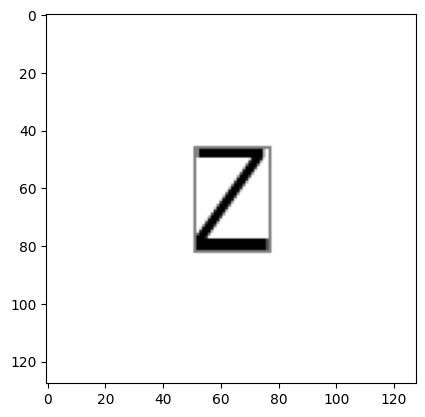



Index: 934306, Letra: j, Fuente: Baskervville-500, variacion: rotate


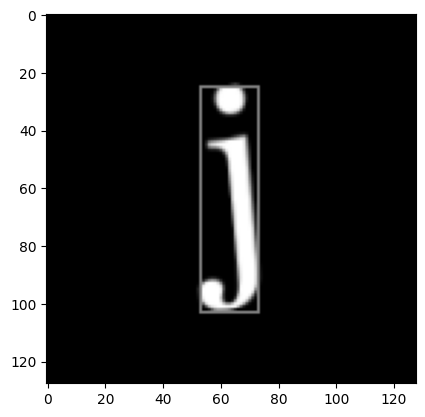



Index: 558608, Letra: n, Fuente: Kay_Pho_Du-600, variacion: invert


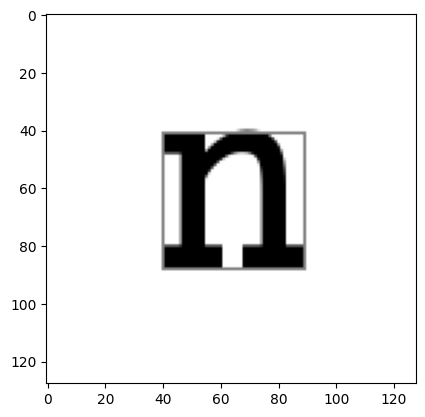



Index: 1133525, Letra: G, Fuente: Geist-500, variacion: rotate


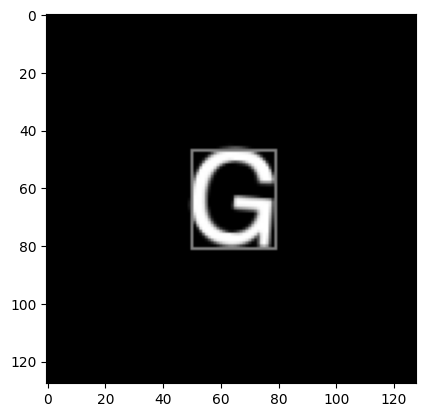



Index: 1104436, Letra: 4, Fuente: Bodoni_Moda_SC-600italic, variacion: rotate


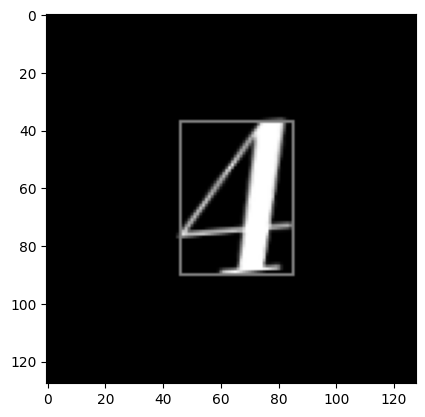



Index: 1044888, Letra: 0, Fuente: IBM_Plex_Sans_Thai-600, variacion: negro


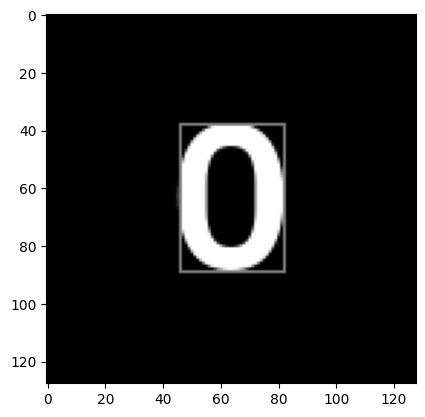



Index: 402453, Letra: 1, Fuente: Anuphan-600, variacion: noise


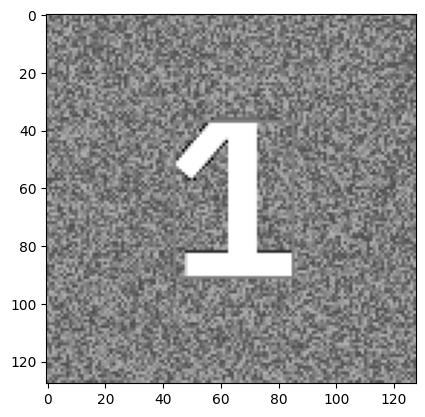



Index: 724932, Letra: u, Fuente: Gentium_Plus-italic, variacion: negro


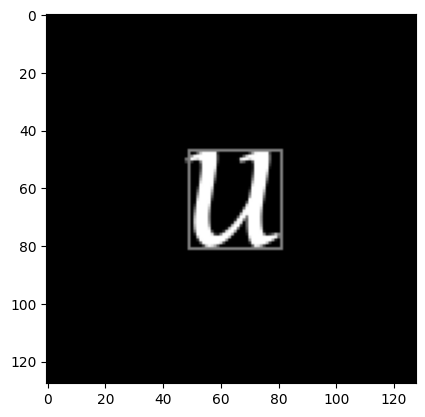



Index: 1229792, Letra: 3, Fuente: Noto_Sans_Gurmukhi-700, variacion: invert


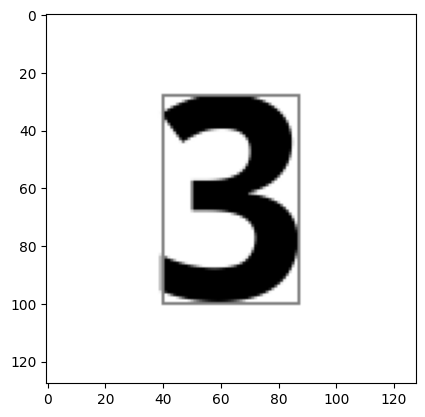



Index: 426455, Letra: X, Fuente: Bai_Jamjuree-500, variacion: rotate


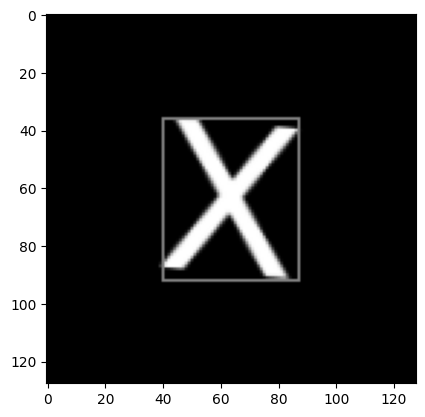



Index: 917862, Letra: X, Fuente: Fira_Sans_Condensed-700, variacion: negro


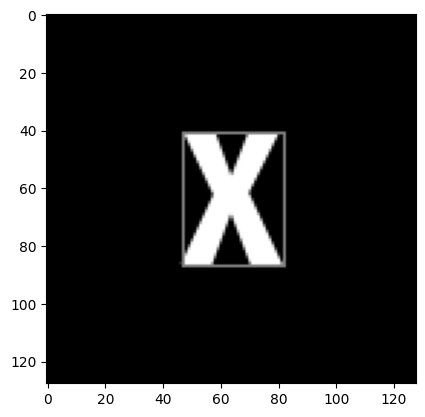



Index: 1074522, Letra: f, Fuente: Maven_Pro-500, variacion: negro


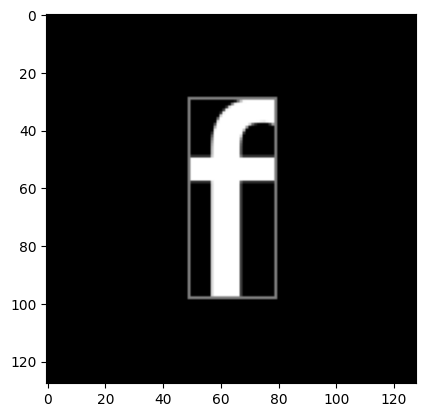



Index: 1076116, Letra: w, Fuente: Eczar-700, variacion: rotate


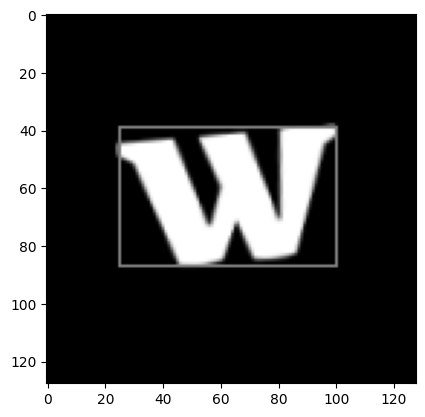



Index: 1382989, Letra: s, Fuente: Inter-900italic, variacion: blur


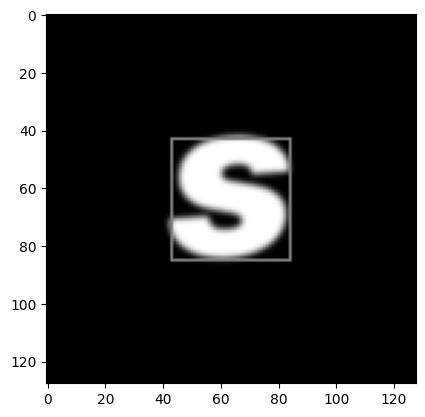



Index: 1028431, Letra: l, Fuente: IBM_Plex_Sans_Devanagari-100, variacion: blur


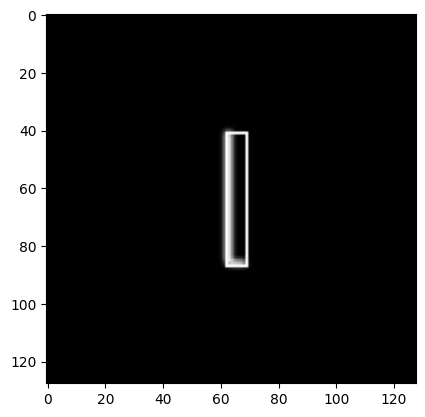



Index: 605199, Letra: 2, Fuente: M_PLUS_Code_Latin-100, variacion: noise


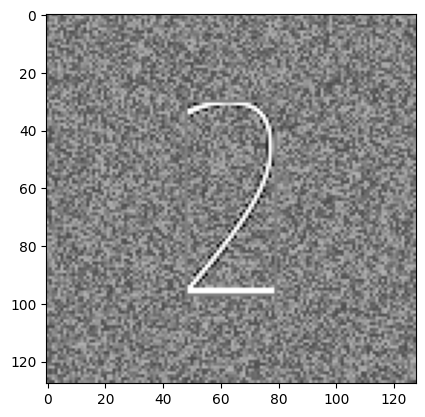



Index: 28464, Letra: g, Fuente: Mona_Sans-800italic, variacion: negro


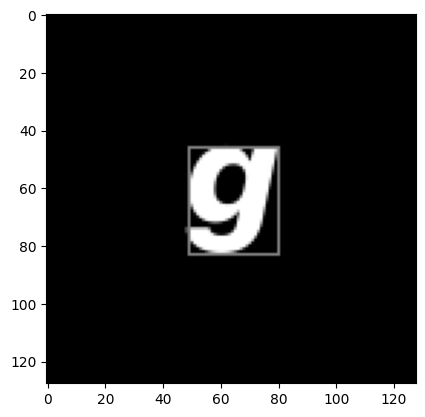



Index: 1449222, Letra: v, Fuente: Alegreya-regular, variacion: negro


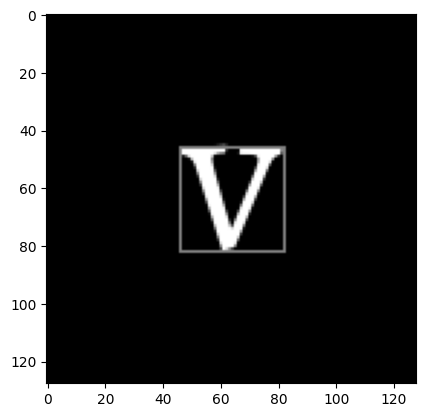



Index: 573065, Letra: e, Fuente: Chivo-700italic, variacion: rotate


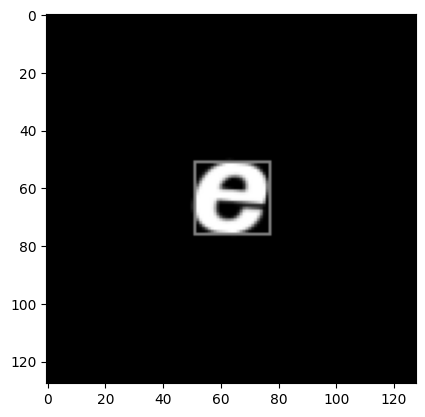



Index: 1118869, Letra: s, Fuente: Baskervville_SC-500, variacion: blur


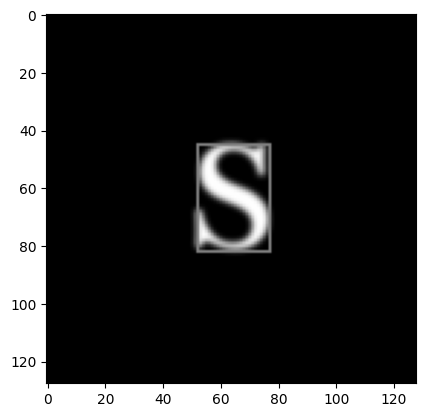

In [21]:
muestra = pandas_dataset.sample(20)
for index, row in muestra.iterrows():
    print(f"Index: {row['index']}, Letra: {row['character']}, Fuente: {row['font_type']}, variacion: {row['background_type']}")
    img_muestra = numpy_dataset[row['index']]['image']
    bbox = numpy_dataset[row['index']]['bbox']
    cv2.rectangle(img_muestra, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (128, 128, 128), 1)
    plt.imshow(img_muestra, cmap='gray')
    plt.show()
    print("\n")

In [22]:
# Crear el directorio si no existe
os.makedirs(carpeta_destino_datasets, exist_ok=True)

# Guardar el dataset de imágenes (arrays numpy) como archivo .npy
numpy_output_path = os.path.join(carpeta_destino_datasets, 'imagenes_dataset.npy')
np.save(numpy_output_path, numpy_dataset)
print(f"Dataset de imágenes guardado en: {numpy_output_path}")

# Guardar el dataset de información (pandas DataFrame) como archivo .csv
pandas_output_path = os.path.join(carpeta_destino_datasets, 'info_imagenes.csv')
pandas_dataset.to_csv(pandas_output_path, index=False)
print(f"Dataset de información guardado en: {pandas_output_path}")

# Guardar el dataset de fuentes utilizadas como archivo .csv
font_output_path = os.path.join(carpeta_destino_datasets, 'data_fuentes.csv')
font_df.to_csv(font_output_path, index=False)
print(f"Dataset de información guardado en: {font_output_path}")

Dataset de imágenes guardado en: /content/datasets/imagenes_dataset.npy
Dataset de información guardado en: /content/datasets/info_imagenes.csv
Dataset de información guardado en: /content/datasets/data_fuentes.csv
